# Propensity Score Matching + Difference-in-Differences

## Objective

This notebook combines Propensity Score Matching (PSM) and Difference-in-Differences (DiD) to estimate the impact of the education support program.

First, participants and non-participants are matched based on observed characteristics. The Difference-in-Differences estimator is then applied to the matched sample.

This approach aims to improve comparability between groups and strengthen causal inference.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf

In [19]:
df = pd.read_csv("../data/synthetic_education_data.csv")

df.head

<bound method NDFrame.head of      student_id class_level gender  treatment  attendance_rate  study_hours  \
0             1          P5   Girl          1             92.3          6.6   
1             2          P6    Boy          1             89.8          3.7   
2             3          P5   Girl          1             95.8         10.9   
3             4          P5    Boy          0             81.2          6.3   
4             5          P5    Boy          0             89.4          6.2   
..          ...         ...    ...        ...              ...          ...   
475         236          P6   Girl          1             78.8         10.9   
476         237          P6    Boy          0             76.1          4.7   
477         238          P6   Girl          1             92.5          4.9   
478         239          P5    Boy          1             88.3          4.8   
479         240          P6   Girl          1             84.7          4.9   

     post      time  

In [20]:
df.columns

Index(['student_id', 'class_level', 'gender', 'treatment', 'attendance_rate',
       'study_hours', 'post', 'time', 'test_score'],
      dtype='str')

## Recreate the Match Sample

In [21]:
baseline = df[
    df["post"] == 0
].copy()

baseline["female"] = (
    baseline["gender"] == "Girl"
).astype(int)

baseline["p6"] = (
    baseline["class_level"] == "P6"
).astype(int)

In [22]:
from sklearn.linear_model import LogisticRegression

X = baseline[
    [
        "female",
        "p6",
        "attendance_rate",
        "study_hours"
    ]
]

y = baseline["treatment"]

ps_model = LogisticRegression()

ps_model.fit(X, y)

baseline["propensity_score"] = (
    ps_model.predict_proba(X)[:,1]
)

In [23]:
baseline.columns

Index(['student_id', 'class_level', 'gender', 'treatment', 'attendance_rate',
       'study_hours', 'post', 'time', 'test_score', 'female', 'p6',
       'propensity_score'],
      dtype='str')

In [25]:
from sklearn.neighbors import NearestNeighbors

treated = baseline[
    baseline["treatment"] == 1
].copy()

control = baseline[
    baseline["treatment"] == 0
].copy()

nn = NearestNeighbors(
    n_neighbors=1
)

nn.fit(
    control[["propensity_score"]]
)

distances, indices = nn.kneighbors(
    treated[["propensity_score"]]
)

matched_controls = control.iloc[
    indices.flatten()
].copy()

In [12]:
baseline.columns

Index(['student_id', 'class_level', 'gender', 'treatment', 'attendance_rate',
       'study_hours', 'post', 'time', 'test_score', 'female', 'p6',
       'propensity_score'],
      dtype='str')

In [26]:
# Constructing the matched sample

matched_pupils = pd.concat(
    [treated, matched_controls]
)

matched_ids = matched_pupils[
    "student_id"
].unique()

matched_df = df[
    df["student_id"].isin(matched_ids)
].copy()

matched_df.shape

(394, 9)

## Estimate PSM + DiD Model

In [27]:
psm_did_model = smf.ols(
    "test_score ~ treatment * post",
    data=matched_df
).fit()

In [28]:
print(
    psm_did_model.summary()
)

                            OLS Regression Results                            
Dep. Variable:             test_score   R-squared:                       0.423
Model:                            OLS   Adj. R-squared:                  0.418
Method:                 Least Squares   F-statistic:                     95.13
Date:                Tue, 21 Jul 2026   Prob (F-statistic):           3.22e-46
Time:                        17:27:55   Log-Likelihood:                -1258.5
No. Observations:                 394   AIC:                             2525.
Df Residuals:                     390   BIC:                             2541.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         72.7029      0.719    101.

In [33]:
results_table = pd.DataFrame({
    "Coefficient": psm_did_model.params,
    "Std_Error": psm_did_model.bse,
    "t_stat": psm_did_model.tvalues,
    "p_value": psm_did_model.pvalues
})

results_table.to_csv(
    "../outputs/tables/psm_did_regression_results.csv"
)

results_table

,Coefficient,Std_Error,t_stat,p_value
Intercept,72.702941,0.719278,101.077709,7.649595e-282
treatment,-0.102166,0.888863,-0.114940,9.085518e-01
post,3.857353,1.017212,3.792083,1.730592e-04
treatment:post,7.516290,1.257042,5.979346,5.065657e-09


In [29]:
psm_did_effect = (
    psm_did_model
    .params["treatment:post"]
)

print(
    f"Estimated PSM + DiD Impact: {psm_did_effect:.2f} points"
)

Estimated PSM + DiD Impact: 7.52 points


## Comparing DiD and PSM + DiD

In [30]:
comparison = pd.DataFrame({
    "Method": [
        "Difference-in-Differences",
        "PSM + Difference-in-Differences"
    ],
    "Impact": [
        7.22,
        psm_did_effect
    ]
})

comparison

,Method,Impact
0,Difference-in-Differences,7.22000
1,PSM + Difference-in-Differences,7.51629


In [31]:
## Exporting the comparison table to a CSV file

comparison.to_csv(
    "../outputs/tables/final_results.csv",
    index=False
)

## Visualizing the Impact

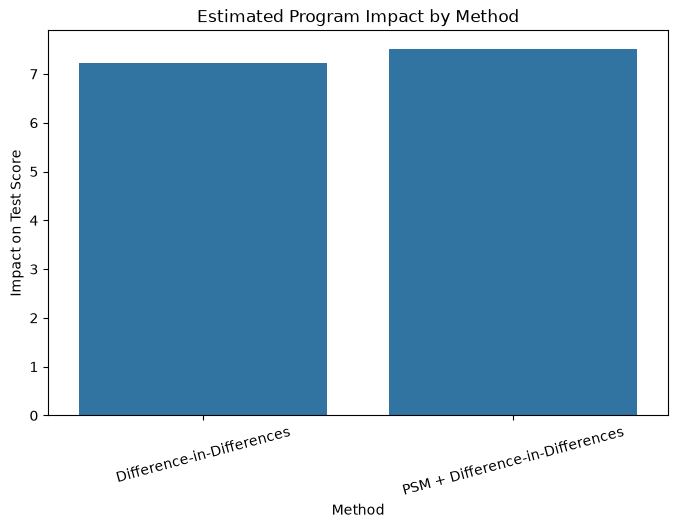

In [32]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Method",
    y="Impact"
)

plt.title(
    "Estimated Program Impact by Method"
)

plt.ylabel(
    "Impact on Test Score"
)

plt.xticks(rotation=15)

plt.savefig(
    "../outputs/figures/impact_estimates.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Interpretation of PSM + Difference-in-Differences Results

The Propensity Score Matching plus Difference-in-Differences (PSM + DiD) model was estimated using a matched sample of treatment and comparison pupils.

### Main Findings

The interaction term (`treatment:post`) represents the estimated impact of the education support program after matching pupils on observable characteristics and comparing changes over time.

- **Estimated program impact:** 7.52 points
- **95% Confidence Interval:** 5.05 to 9.99 points
- **p-value:** < 0.001

This result indicates that pupils who participated in the education support program achieved test scores that were approximately **7.52 points higher** than would have been expected in the absence of the program.

### Additional Results

The coefficient on `post` is positive and statistically significant:

- **Post coefficient:** 3.86 points

This suggests that test scores improved over time for all pupils, regardless of participation status.

The coefficient on `treatment` is close to zero and statistically insignificant:

- **Treatment coefficient:** -0.10 points
- **p-value:** 0.909

This indicates that after matching, there were no meaningful baseline differences in average test scores between treatment and comparison pupils. This finding provides additional evidence that the matching procedure successfully improved comparability between groups.

### Model Performance

The model explains approximately:

- **R² = 0.423**

This means that around 42.3% of the variation in test scores is explained by the variables included in the model.

### Comparison with the DiD Estimate

| Method | Estimated Impact |
|----------|----------------:|
| Difference-in-Differences | 7.22 |
| PSM + Difference-in-Differences | 7.52 |

The similarity between the two estimates suggests that the findings are robust to observable differences between treatment and comparison pupils. Matching slightly increased the estimated impact, but the overall conclusion remains unchanged.

### Evaluation Takeaway

The education support program was associated with a statistically significant improvement in pupil learning outcomes. After improving baseline comparability through propensity score matching, the estimated impact remained strong at approximately 7.5 test-score points, providing additional confidence in the robustness of the findings.